<a href="https://colab.research.google.com/github/KarinaSelingardi/ESTUDOS-DE-PYTHON/blob/main/estacao_agua_grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import heapq

# --- Dados do grafo (distâncias em km) ---
graph = {
    "ETA_1_2": {
        "Eulina (8)": 6.91, "Vila Georgina (23)": 7.41, "Colinas Ermitage (4)": 16.33,
        "Carlos Lourenço (2)": 11.72, "Paranapanema (34)": 13.81, "Zona Sul (5)": 14.72
    },
    "ETA_3_4": {
        "Eulina (8)": 6.43, "Colinas Ermitage (4)": 10.80, "Vila Georgina (23)": 17.24, "Carlos Lourenço (2)": 17.95
    }
}



In [ ]:
# --- Dijkstra (de origem até todos os destinos) ---
def dijkstra(graph, start):
    distances = {node: float("inf") for node in graph}  # distâncias iniciais
    # também precisamos incluir os destinos
    for node_dict in graph.values():
        for node in node_dict:
            if node not in distances:
                distances[node] = float("inf")
    distances[start] = 0
    pq = [(0, start)]  # (distância, nó)
    previous = {node: None for node in distances}

    while pq:
        current_distance, current_node = heapq.heappop(pq)
        if current_distance > distances[current_node]:
            continue
        if current_node in graph:
            for neighbor, weight in graph[current_node].items():
                distance = current_distance + weight
                if distance < distances[neighbor]:
                    distances[neighbor] = distance
                    previous[neighbor] = current_node
                    heapq.heappush(pq, (distance, neighbor))
    return distances, previous

In [ ]:
# Exemplo: Calcular distâncias e predecessores a partir de 'ETA_1_2'
start_node = "ETA_1_2"
distances, previous = dijkstra(graph, start_node)

# Exibir as menores distâncias
print(f"Menores distâncias a partir de {start_node}:")
for node, distance in distances.items():
    print(f"Para {node}: {distance:.2f} km")

Menores distâncias a partir de ETA_1_2:
Para ETA_1_2: 0.00 km
Para ETA_3_4: inf km
Para Eulina (8): 6.91 km
Para Vila Georgina (23): 7.41 km
Para Colinas Ermitage (4): 16.33 km
Para Carlos Lourenço (2): 11.72 km
Para Paranapanema (34): 13.81 km
Para Zona Sul (5): 14.72 km


In [ ]:
# Função para reconstruir o caminho
def reconstruct_path(previous, start_node, end_node):
    path = []
    current_node = end_node
    while current_node is not None:
        path.insert(0, current_node)
        current_node = previous[current_node]
    if path[0] == start_node:
        return path
    else:
        return [] # Retorna lista vazia se não houver caminho do start_node para o end_node

# Exibir os caminhos mais curtos
print(f"\nCaminhos mais curtos a partir de {start_node}:")
# Precisamos iterar sobre todos os nós no dicionário de distâncias para encontrar todos os destinos possíveis
all_nodes = set(distances.keys())

for end_node in all_nodes:
    if end_node != start_node:
        path = reconstruct_path(previous, start_node, end_node)
        if path:
            print(f"Para {end_node}: {' -> '.join(path)}")
        else:
            print(f"Não há caminho de {start_node} para {end_node}")


Caminhos mais curtos a partir de ETA_1_2:
Para Eulina (8): ETA_1_2 -> Eulina (8)
Para Colinas Ermitage (4): ETA_1_2 -> Colinas Ermitage (4)
Para Carlos Lourenço (2): ETA_1_2 -> Carlos Lourenço (2)
Para Paranapanema (34): ETA_1_2 -> Paranapanema (34)
Para Vila Georgina (23): ETA_1_2 -> Vila Georgina (23)
Não há caminho de ETA_1_2 para ETA_3_4
Para Zona Sul (5): ETA_1_2 -> Zona Sul (5)


In [ ]:
# Calcular distâncias e predecessores a partir de 'ETA_3_4'
start_node_eta3 = "ETA_3_4"
distances_eta3, previous_eta3 = dijkstra(graph, start_node_eta3)

# Exibir as menores distâncias a partir de 'ETA_3_4'
print(f"Menores distâncias a partir de {start_node_eta3}:")
for node, distance in distances_eta3.items():
    print(f"Para {node}: {distance:.2f} km")

# Exibir os caminhos mais curtos a partir de 'ETA_3_4'
print(f"\nCaminhos mais curtos a partir de {start_node_eta3}:")
all_nodes = set(distances_eta3.keys())

for end_node in all_nodes:
    if end_node != start_node_eta3:
        path = reconstruct_path(previous_eta3, start_node_eta3, end_node)
        if path:
            print(f"Para {end_node}: {' -> '.join(path)}")
        else:
            print(f"Não há caminho de {start_node_eta3} para {end_node}")

Menores distâncias a partir de ETA_3_4:
Para ETA_1_2: inf km
Para ETA_3_4: 0.00 km
Para Eulina (8): 6.43 km
Para Vila Georgina (23): 17.24 km
Para Colinas Ermitage (4): 10.80 km
Para Carlos Lourenço (2): 17.95 km
Para Paranapanema (34): inf km
Para Zona Sul (5): inf km

Caminhos mais curtos a partir de ETA_3_4:
Para Eulina (8): ETA_3_4 -> Eulina (8)
Para Colinas Ermitage (4): ETA_3_4 -> Colinas Ermitage (4)
Para Carlos Lourenço (2): ETA_3_4 -> Carlos Lourenço (2)
Não há caminho de ETA_3_4 para ETA_1_2
Não há caminho de ETA_3_4 para Paranapanema (34)
Para Vila Georgina (23): ETA_3_4 -> Vila Georgina (23)
Não há caminho de ETA_3_4 para Zona Sul (5)


# Task
Visualize the graph represented by the `graph` dictionary.

## Instalar bibliotecas

### Subtask:
Instalar as bibliotecas `networkx` e `matplotlib` para manipulação e visualização de grafos.


**Reasoning**:
Install the necessary libraries for graph manipulation and visualization.



In [ ]:
%pip install networkx matplotlib

## Criar objeto grafo

### Subtask:
Criar um objeto grafo usando a biblioteca `networkx` a partir do dicionário `graph`.


**Reasoning**:
Create a directed graph object and add edges to it based on the provided graph dictionary.



In [ ]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add edges from the graph dictionary
for source, destinations in graph.items():
    for destination, weight in destinations.items():
        G.add_edge(source, destination, weight=weight)

## Desenhar o grafo

### Subtask:
Utilizar a biblioteca `matplotlib` para desenhar o grafo, exibindo os nós e as arestas com seus pesos.


**Reasoning**:
Visualize the graph by drawing nodes, edges, and labels using matplotlib and networkx.



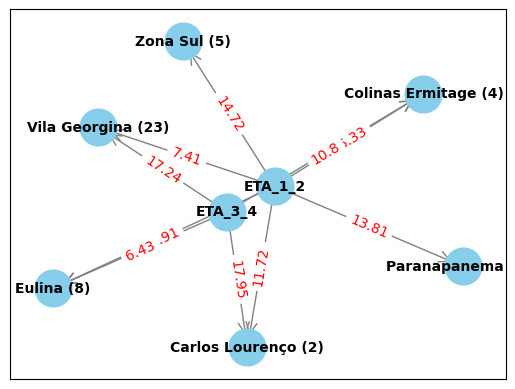

In [ ]:
import matplotlib.pyplot as plt

# Define the layout for the graph visualization
pos = nx.spring_layout(G)

# Draw the nodes of the graph
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')

# Draw the edges of the graph
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color='gray', arrowstyle='->', arrowsize=20)

# Draw the labels for the nodes
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Get the edge labels (weights) from the graph
edge_labels = nx.get_edge_attributes(G, 'weight')

# Draw the edge labels
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Display the plotted graph
plt.show()

## Summary:

### Data Analysis Key Findings

*   The required libraries (`networkx` and `matplotlib`) were confirmed to be installed.
*   A directed graph object was successfully created using the `networkx` library based on the provided dictionary structure.
*   The graph visualization was generated using `matplotlib`, displaying nodes, directed edges, node labels, and edge weights.

### Insights or Next Steps

*   The visualization provides a clear representation of the graph's structure and the weighted relationships between nodes.
*   Depending on the task, further analysis could involve computing graph metrics (e.g., shortest paths, centrality) or exploring alternative visualization layouts.
